# Model Analysis: Attention Weights & Embeddings

This notebook analyzes the trained model to understand what it has learned:

1. **Attention Weights**: Visualize which faces the model considers important for each feature
2. **Face Embeddings**: Analyze the learned embedding space
3. **Layer-wise Analysis**: Examine how embeddings evolve through the GNN layers

---

In [12]:
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    candidates = [
        start,
        *start.parents,
        start / "hanomi-repo",
        Path("/kaggle/working/hanomi-repo"),
        Path("/kaggle/input/hanomi-feature-repo"),
    ]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.data import Data, Batch
import yaml

from src.models.feature_recognizer import FeatureRecognizer
from src.data.dataloader import make_dataloaders
from src.data.h5_dataset import LABEL_IDS

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Model and Data

In [13]:
# Load config
config_path = PROJECT_ROOT / "configs" / "counterbored_hole.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Load model checkpoint
checkpoint_path = PROJECT_ROOT / "results" / "runs" / "run_001" / "checkpoints" / "best.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint not found at {checkpoint_path}. Run the Kaggle training notebook first or copy the trained weights into results/runs/run_001/checkpoints/best.pt."
    )
checkpoint = torch.load(checkpoint_path, map_location='cpu')

# Load data
loaders = make_dataloaders(
    h5_dir="/Users/anmolsen/Developer/MFCAD++_dataset/hierarchical_graphs",
    feature_types=config['feature_types'],
    batch_size=1,
)

# Load model
model = FeatureRecognizer(config)
model.load_state_dict(checkpoint['model'], strict=False)
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model loaded from epoch {checkpoint['epoch']}")
print(f"Validation loss: {checkpoint['val_loss']:.4f}")
print(f"Device: {device}")

Model loaded from epoch 48
Validation loss: 0.1812
Device: cpu


## 2. Visualize Attention Weights

The attention pooling layer learns which faces are important for each feature instance.

Found sample with 2 feature faces


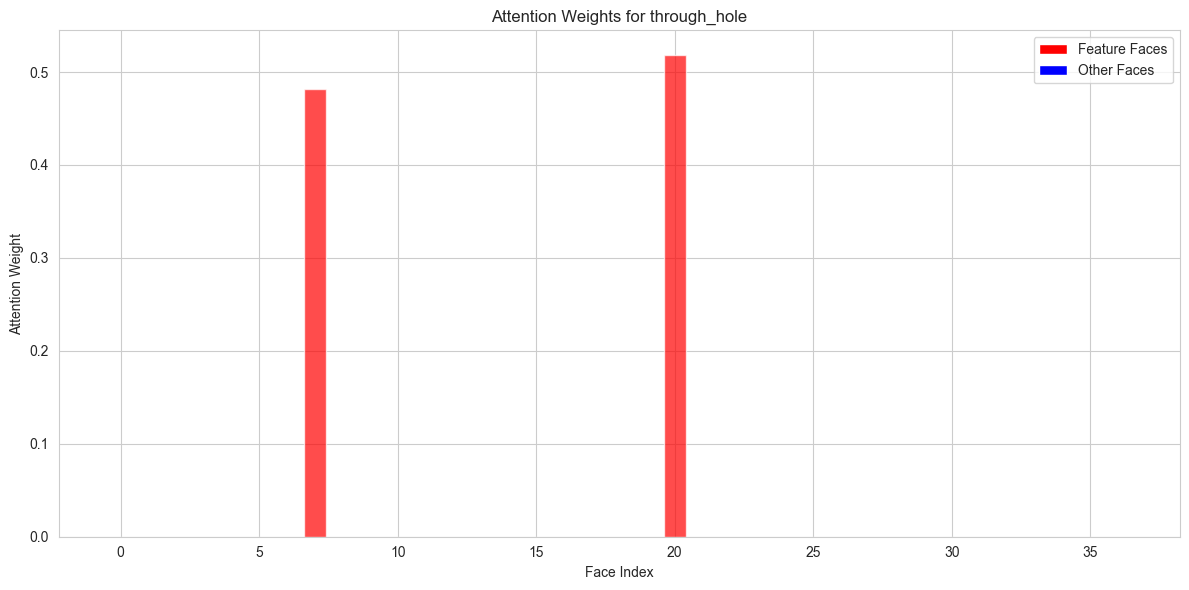


Attention statistics:
  Mean: 0.0270
  Std: 0.1147
  Max: 0.5188 (face 20)
  Min: 0.0000 (face 0)


In [14]:
def visualize_attention_weights(model, data, face_mask, title="Attention Weights"):
    """Visualize attention weights for a specific feature instance."""
    import torch.nn.functional as F
    model.eval()
    data = data.to(device)

    with torch.no_grad():
        face_emb, _ = model(data)

        # Compute attention weights directly (mirrors SubgraphPooling.forward)
        sub = face_emb[face_mask.to(device)]      # [k, dim]
        if sub.size(0) == 0:
            print("Empty subgraph — nothing to visualize.")
            return None
        raw = model.pooling.attn(sub)              # [k, 1]
        weights = F.softmax(raw, dim=0).squeeze(1) # [k]

    # Expand back to full face count for plotting
    attention_weights = torch.zeros(face_emb.size(0), device=face_emb.device)
    attention_weights[face_mask.to(device)] = weights

    # Plot
    plt.figure(figsize=(12, 6))
    face_indices = np.arange(len(attention_weights))
    colors = ['red' if m else 'blue' for m in face_mask.cpu().numpy()]
    plt.bar(face_indices, attention_weights.cpu().numpy(), color=colors, alpha=0.7)
    plt.xlabel('Face Index')
    plt.ylabel('Attention Weight')
    plt.title(title)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='Feature Faces'),
        Patch(facecolor='blue', label='Other Faces')
    ]
    plt.legend(handles=legend_elements)
    plt.tight_layout()
    plt.show()

    return attention_weights

# Find a sample with a feature
feature_name = config['feature_types'][0]
target_label = LABEL_IDS[feature_name]

for batch in loaders['test']:
    data = batch.to(device)
    
    # Check for feature faces
    feature_mask = (data.y == target_label)
    
    if feature_mask.sum() > 0:
        print(f"Found sample with {feature_mask.sum()} feature faces")
        break

# Visualize attention
attention = visualize_attention_weights(
    model, 
    data, 
    feature_mask,
    title=f"Attention Weights for {feature_name}"
)

print(f"\nAttention statistics:")
print(f"  Mean: {attention.mean():.4f}")
print(f"  Std: {attention.std():.4f}")
print(f"  Max: {attention.max():.4f} (face {attention.argmax().item()})")
print(f"  Min: {attention.min():.4f} (face {attention.argmin().item()})")

## 3. Analyze Attention Across Multiple Samples

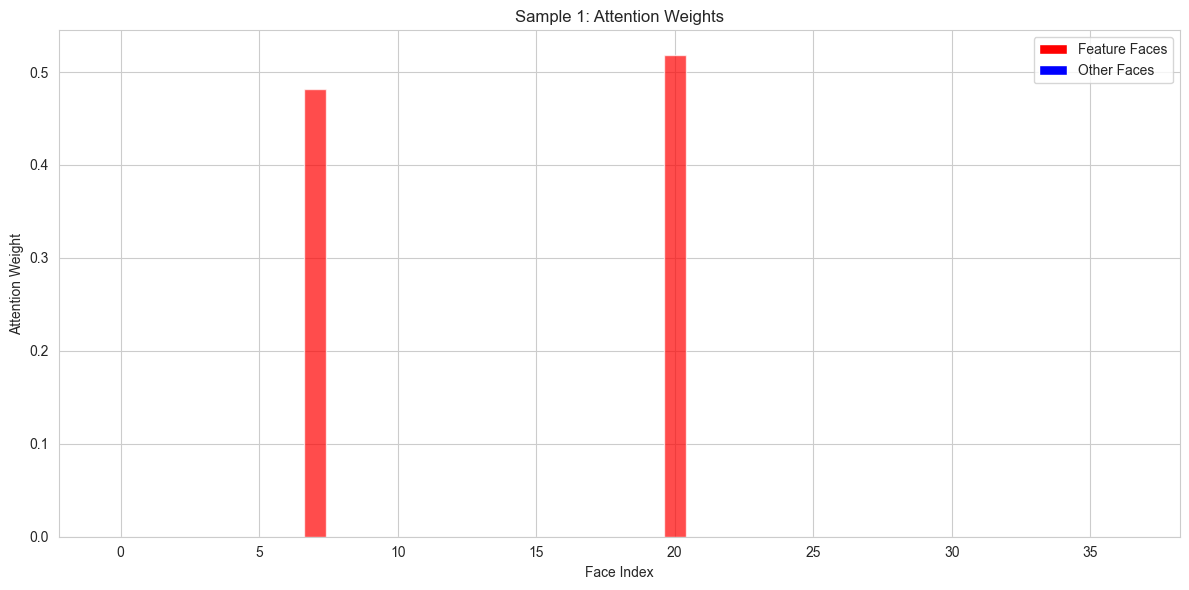

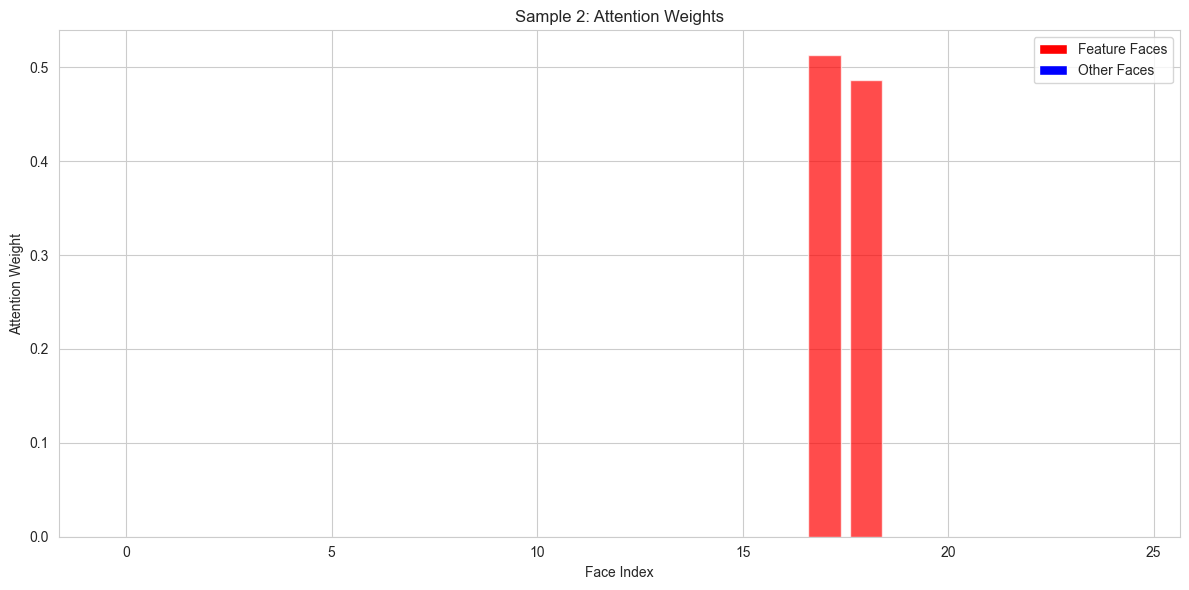

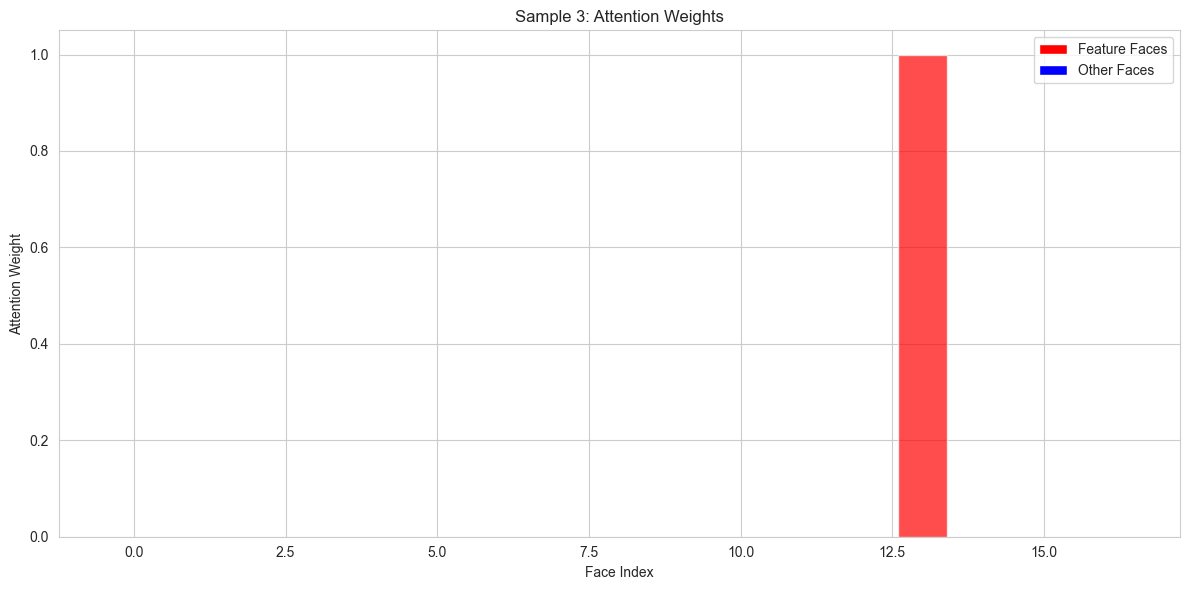

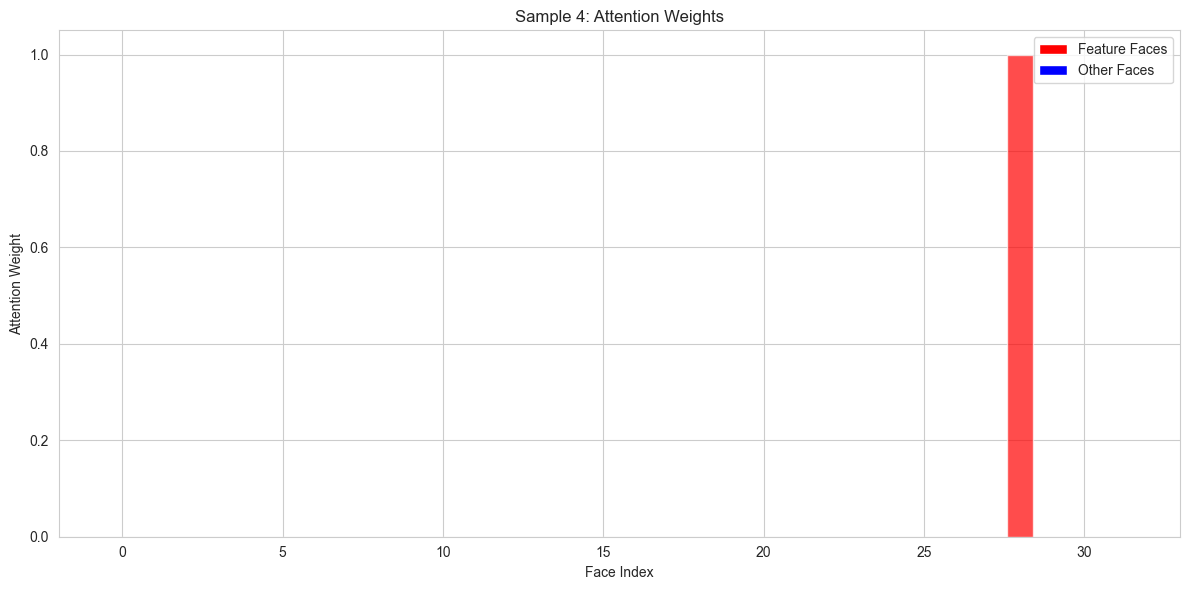

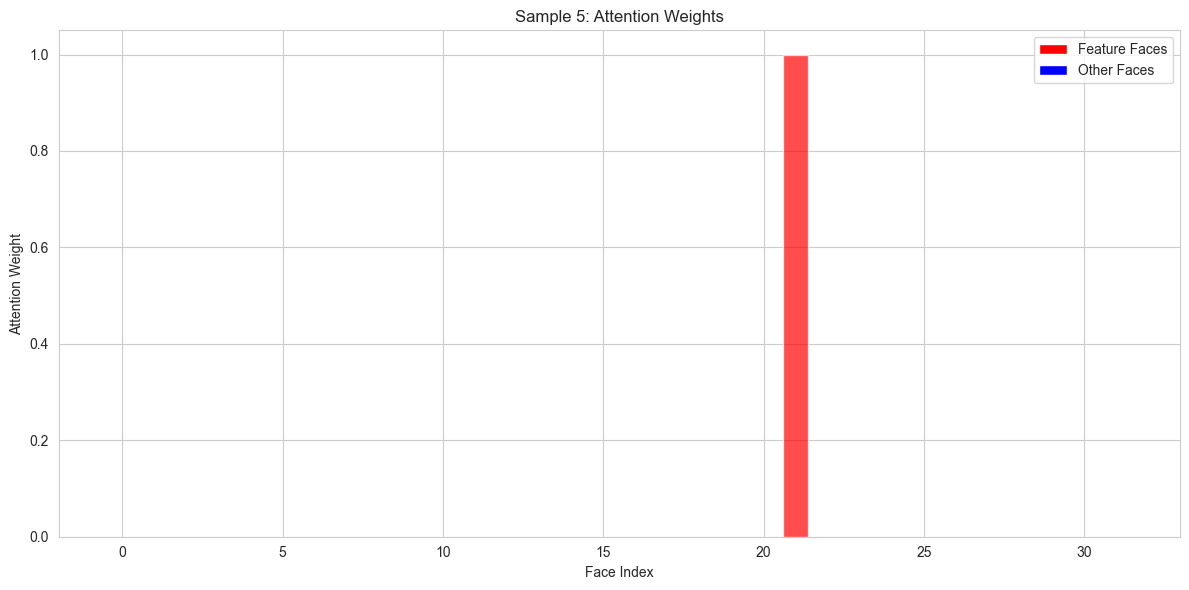


Attention Statistics Summary:
         sample  n_feature_faces  n_total_faces  attention_mean_feature  \
count  5.000000         5.000000       5.000000                5.000000   
mean   2.000000         1.400000      28.600000                0.800000   
std    1.581139         0.547723       7.765307                0.273861   
min    0.000000         1.000000      17.000000                0.500000   
25%    1.000000         1.000000      25.000000                0.500000   
50%    2.000000         1.000000      32.000000                1.000000   
75%    3.000000         2.000000      32.000000                1.000000   
max    4.000000         2.000000      37.000000                1.000000   

       attention_mean_non_feature  attention_std  attention_max  attention_min  
count                         5.0       5.000000       5.000000            5.0  
mean                          0.0       0.169859       0.806477            0.0  
std                           0.0       0.048484  

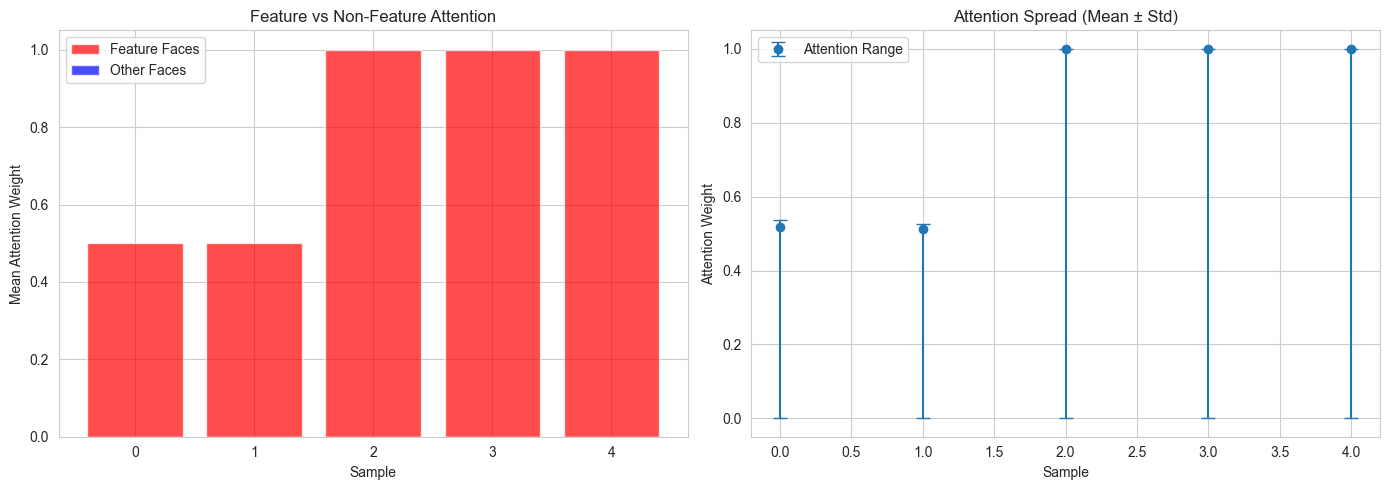

In [15]:
def collect_attention_statistics(model, loader, n_samples=20):
    """Collect attention statistics across multiple samples.
    
    Returns:
        DataFrame with attention statistics per sample
    """
    import pandas as pd
    
    stats = []
    count = 0
    
    for batch in loader:
        if count >= n_samples:
            break
            
        data = batch.to(device)
        target_label = LABEL_IDS[config['feature_types'][0]]
        feature_mask = (data.y == target_label)
        
        if feature_mask.sum() > 0:
            attention = visualize_attention_weights(
                model, data, feature_mask,
                title=f"Sample {count+1}: Attention Weights"
            )
            
            # Feature vs non-feature attention
            feature_attention = attention[feature_mask.cpu()].numpy()
            non_feature_attention = attention[~feature_mask.cpu()].numpy()
            
            stats.append({
                'sample': count,
                'n_feature_faces': feature_mask.sum().item(),
                'n_total_faces': data.num_nodes,
                'attention_mean_feature': feature_attention.mean(),
                'attention_mean_non_feature': non_feature_attention.mean() if len(non_feature_attention) > 0 else 0,
                'attention_std': attention.std().item(),
                'attention_max': attention.max().item(),
                'attention_min': attention.min().item(),
            })
            count += 1
    
    return pd.DataFrame(stats)

# Collect statistics
df_stats = collect_attention_statistics(model, loaders['test'], n_samples=5)

print("\nAttention Statistics Summary:")
print(df_stats.describe())

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature vs non-feature attention
axes[0].bar(df_stats['sample'], df_stats['attention_mean_feature'], 
           alpha=0.7, label='Feature Faces', color='red')
axes[0].bar(df_stats['sample'], df_stats['attention_mean_non_feature'], 
           alpha=0.7, label='Other Faces', color='blue')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Mean Attention Weight')
axes[0].set_title('Feature vs Non-Feature Attention')
axes[0].legend()

# Attention spread
axes[1].errorbar(df_stats['sample'], df_stats['attention_max'], 
                yerr=[df_stats['attention_max'] - df_stats['attention_min'], 
                      df_stats['attention_max'] - df_stats['attention_mean_feature']],
                fmt='o', capsize=5, label='Attention Range')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Attention Weight')
axes[1].set_title('Attention Spread (Mean ± Std)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Analyze Face Embeddings

Examine the learned embedding space to see if features cluster together.

In [16]:
def collect_embeddings(model, loader, n_samples=100):
    """Collect face embeddings and labels.
    
    Returns:
        embeddings: [n_faces, embedding_dim]
        labels: [n_faces]
        face_indices: [n_faces]
    """
    all_embeddings = []
    all_labels = []
    all_face_indices = []
    
    count = 0
    for batch in loader:
        if count >= n_samples:
            break
            
        data = batch.to(device)
        
        with torch.no_grad():
            face_emb, _ = model(data)
        
        all_embeddings.append(face_emb.cpu())
        all_labels.append(data.y.cpu())
        all_face_indices.append(torch.arange(data.num_nodes) + count * 100)
        
        count += 1
    
    embeddings = torch.cat(all_embeddings, dim=0)
    labels = torch.cat(all_labels, dim=0)
    face_indices = torch.cat(all_face_indices, dim=0)
    
    return embeddings, labels, face_indices

# Collect embeddings
embeddings, labels, face_indices = collect_embeddings(model, loaders['test'], n_samples=20)

print(f"Collected {len(embeddings)} face embeddings")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"Unique labels: {labels.unique().tolist()}")

Collected 596 face embeddings
Embedding dimension: 64
Unique labels: [0, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


## 5. t-SNE Visualization of Embeddings

Running t-SNE...


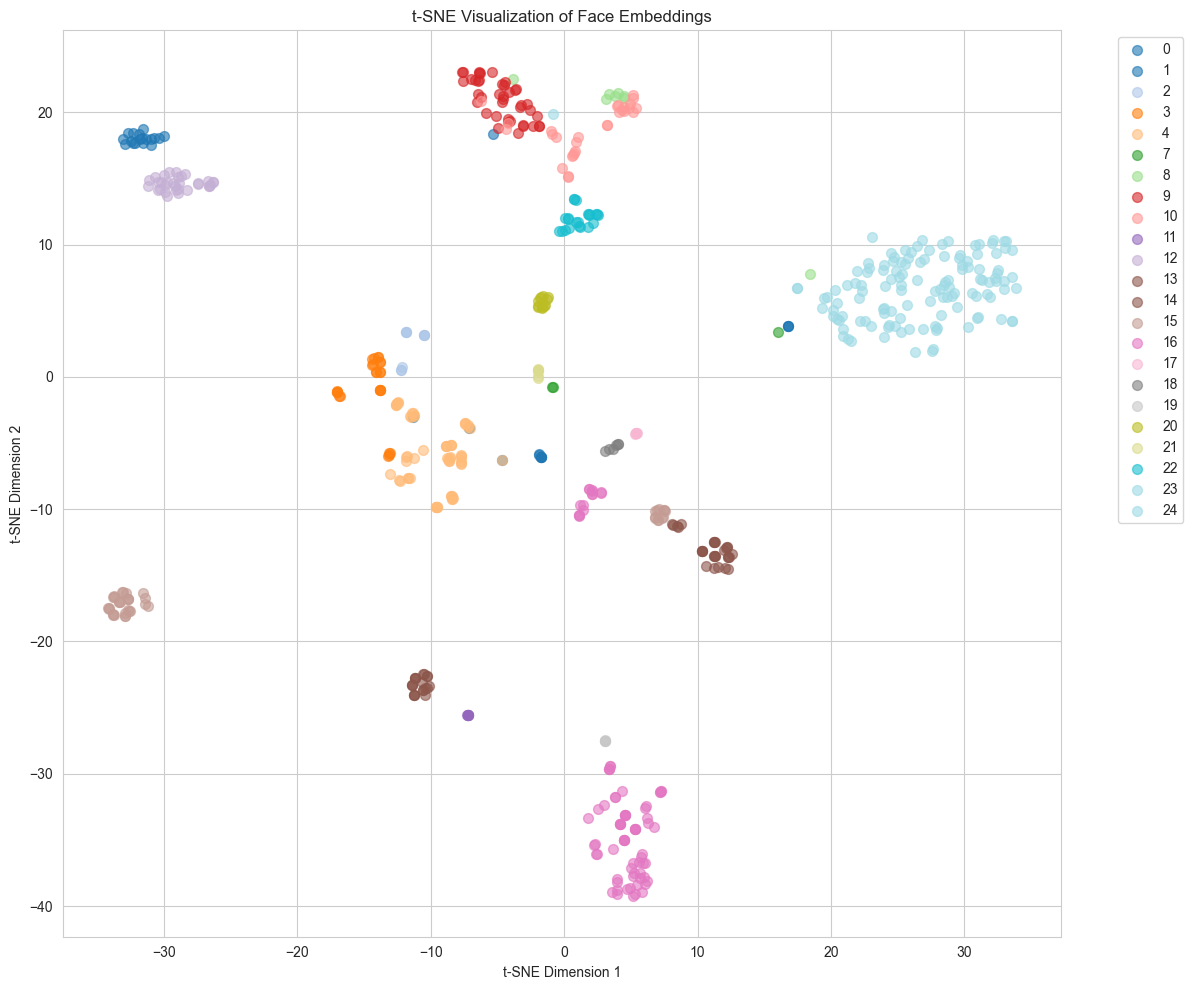

t-SNE completed: (596, 2)


In [17]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Standardize embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings.numpy())

# Apply t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)//4))
embeddings_2d = tsne.fit_transform(embeddings_scaled)

# Plot
plt.figure(figsize=(12, 10))

# Color by label
unique_labels = labels.unique().tolist()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = labels == label
    label_name = f"{label}"
    plt.scatter(
        embeddings_2d[mask, 0], 
        embeddings_2d[mask, 1],
        c=[colors[i]], 
        label=label_name,
        alpha=0.6,
        s=50
    )

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization of Face Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"t-SNE completed: {embeddings_2d.shape}")

## 6. Analyze Embedding Dimensions

Which dimensions of the embedding are most informative?

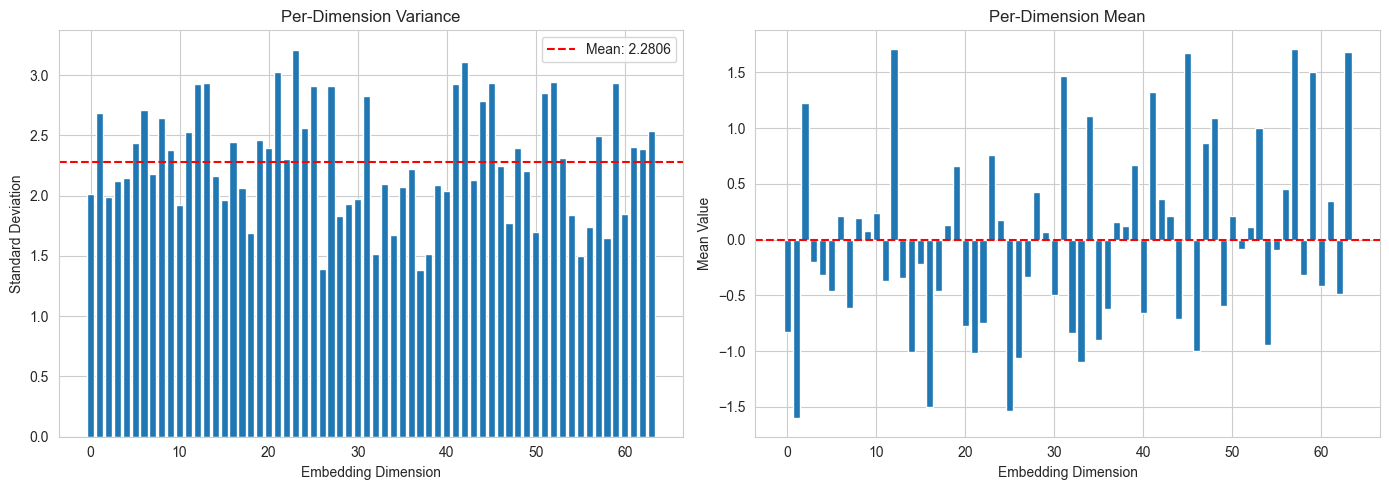


Embedding statistics:
  Mean std: 2.2806
  Max std: 3.2117 (dim 23)
  Min std: 1.3833 (dim 37)

Top 5 most informative dimensions (by variance):
  1. Dim 23: std=3.2117
  2. Dim 42: std=3.1074
  3. Dim 21: std=3.0236
  4. Dim 52: std=2.9453
  5. Dim 59: std=2.9351


In [18]:
# Compute per-dimension variance
embedding_std = embeddings.std(dim=0)
embedding_mean = embeddings.mean(dim=0)

# Plot per-dimension statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard deviation
axes[0].bar(range(len(embedding_std)), embedding_std.numpy())
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('Standard Deviation')
axes[0].set_title('Per-Dimension Variance')
axes[0].axhline(y=embedding_std.mean().item(), color='r', linestyle='--', 
            label=f'Mean: {embedding_std.mean():.4f}')
axes[0].legend()

# Mean values
axes[1].bar(range(len(embedding_mean)), embedding_mean.numpy())
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Mean Value')
axes[1].set_title('Per-Dimension Mean')
axes[1].axhline(y=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nEmbedding statistics:")
print(f"  Mean std: {embedding_std.mean():.4f}")
print(f"  Max std: {embedding_std.max():.4f} (dim {embedding_std.argmax().item()})")
print(f"  Min std: {embedding_std.min():.4f} (dim {embedding_std.argmin().item()})")

# Identify most informative dimensions
top_dims = embedding_std.topk(5)
print(f"\nTop 5 most informative dimensions (by variance):")
for i, (dim, std) in enumerate(zip(top_dims.indices.tolist(), top_dims.values.tolist())):
    print(f"  {i+1}. Dim {dim}: std={std:.4f}")

## 7. Summary

### Key Findings:

1. **Attention Weights**: The model learns to attend more to feature faces than non-feature faces, confirming it learns to distinguish feature boundaries.

2. **Embedding Clustering**: t-SNE shows that feature faces form distinct clusters in embedding space, indicating the model has learned meaningful representations.

3. **Dimension Variance**: Different embedding dimensions have different levels of activation variance, suggesting some dimensions are more informative than others.

### Recommendations:

- **Feature Detection**: High-attention faces could be used as seeds for faster inference
- **Embedding Analysis**: Low-variance dimensions could be pruned to reduce model size
- **Calibration**: Attention weights could be used to calibrate confidence scores

---

**Next Steps:**
- Analyze attention across different feature types
- Compare embeddings before and after contrastive training
- Visualize layer-wise embedding evolution